# Backus–Gilbert Estimators with Data Errors: Minkowski-Sum Formulation

## Problem setting

We consider the same continuous inverse problem as in `dli.ipynb`:

$$
\tilde{\mathbf{d}} = G\bar{m} + \boldsymbol{\eta}, \qquad
\bar{\mathbf{p}} = \mathcal{T}\bar{m},
$$

with model space $\mathcal{M} = L^2([0,1])$, data space $\mathcal{D} \cong \mathbb{R}^{N_d}$, and property space $\mathcal{P} \cong \mathbb{R}^{2}$.

## Incorporating data errors

Following *theory.txt* §"Incorporating data errors into Backus–Gilbert estimators", fix a linear estimator
$X : \mathcal{D} \to \mathcal{P}$ and write

$$
\tilde{\mathbf{p}} := X\tilde{\mathbf{d}}, \qquad
H := \mathcal{T} - XG.
$$

The exact property $\bar{\mathbf{p}}$ then decomposes as

$$
\bar{\mathbf{p}} = \tilde{\mathbf{p}} + H\bar{m} - X\boldsymbol{\eta}.
$$

Assuming
- a Gaussian data-error law with covariance $\mathbf{C}_\mathcal{D}$ and confidence scalar $s > 0$, giving the data-confidence *ellipsoid*

$$
\mathcal{V}_\mathcal{D} = \Bigl\{\mathbf{d} \in \mathcal{D} : \tfrac{1}{2}\langle \mathbf{C}_\mathcal{D}^{-1}\mathbf{d},\mathbf{d}\rangle_\mathcal{D} \le s^2 \Bigr\},
$$

- a model prior *ball* $\mathcal{B} = B_r(m_0) \subset \mathcal{M}$,

the admissible property vectors lie in the **Minkowski sum**

$$
\mathcal{U} \subseteq \tilde{\mathbf{p}} + H\mathcal{B} + X\mathcal{V}_\mathcal{D}.
$$

The trace-norm design functional

$$
J(X) = r^2\,\mathrm{tr}(HH^*) + 2s^2\,\mathrm{tr}(X\mathbf{C}_\mathcal{D}X^*)
$$

is minimised by the **optimal estimator**

$$
X^\star = \mathcal{T}\,G^*\!\bigl(GG^* + 2s^2 r^{-2}\mathbf{C}_\mathcal{D}\bigr)^{-1}.
$$

This notebook sets up the problem ingredients, constructs the admissible property region, and includes diagnostics that separate model and data contributions so runs with different $N_d$ can be compared fairly.

In [1]:
from intervalinf import IntervalDomain, Lebesgue, Function
from intervalinf import IntegrationConfig, ParallelConfig, LebesgueIntegrationConfig, LebesgueParallelConfig
from intervalinf.providers import NormalModesProvider, BumpFunctionProvider
from intervalinf.operators import SOLAOperator

from pygeoinf import EuclideanSpace, LinearOperator
from pygeoinf.convex_analysis import BallSupportFunction, EllipsoidSupportFunction, SupportFunction
from pygeoinf.linear_solvers import CholeskySolver

import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import chi2

# Figures folder
figures_folder = 'bg_with_errors_minkowski_figures'
os.makedirs(figures_folder, exist_ok=True)


## Integration and Parallel Configuration

Configure numerical integration and parallelisation settings for all operators.
With only $N_d = 5$ data this is light, but we keep the same style as `dli.ipynb`.

In [2]:
# =============================================================================
# INTEGRATION AND PARALLEL CONFIGURATION
# =============================================================================

Lebesgue_integration_cfg = LebesgueIntegrationConfig(
    inner_product=IntegrationConfig(method='simpson', n_points=500),
    dual=IntegrationConfig(method='simpson', n_points=500),
    general=IntegrationConfig(method='simpson', n_points=500),
)

sola_integration_cfg = IntegrationConfig(
    method='simpson',
    n_points=1000,
)

parallel_cfg = ParallelConfig(
    enabled=True,
    n_jobs=12,  # modest: only 5 data and 2 properties
)

print("Configuration loaded:")
print(f"  SOLA integration: {sola_integration_cfg.method}, {sola_integration_cfg.n_points} points")
print(f"  Parallel: {'enabled' if parallel_cfg.enabled else 'disabled'}, {parallel_cfg.n_jobs} jobs")

Configuration loaded:
  SOLA integration: simpson, 1000 points
  Parallel: enabled, 12 jobs


## Creating the Spaces

We use the same $L^2([0,1])$ model space as `dli.ipynb`.
The data space $\mathcal{D} \cong \mathbb{R}^{N_d}$ has the dimension chosen in the setup cell,
and the property space $\mathcal{P} \cong \mathbb{R}^{N_p}$ has $N_p = 2$ dimensions,
corresponding to two bump-function targets at $x = 0.25$ and $x = 0.75$.

In [3]:
# Create function domain and model / data / property spaces
function_domain = IntervalDomain(0, 1)

M = Lebesgue(
    0,
    function_domain,
    basis=None,
    integration_config=Lebesgue_integration_cfg,
    parallel_config=parallel_cfg,
)

N_d = 100   # number of data
N_p = 2   # number of properties

D = EuclideanSpace(N_d)
P = EuclideanSpace(N_p)

x = function_domain.uniform_mesh(1000)
print(f"Model space M: L^2([{function_domain.a}, {function_domain.b}])")
print(f"Data space  D: R^{N_d}")
print(f"Property space P: R^{N_p}")

Model space M: L^2([0.0, 1.0])
Data space  D: R^100
Property space P: R^2


In [4]:
# Create forward operator G (N_d sensitivity kernels via NormalModesProvider)
# and property operator T (N_p=2 bump-function kernels via BumpFunctionProvider).
# Same provider pattern as dli.ipynb; random_state fixed for reproducibility.

width = 0.3  # bump width (wider than dli.ipynb to fill [0,1] with only 2 targets)
centers = np.array([0.25, 0.75])  # two symmetric property targets

normal_modes_provider = NormalModesProvider(
    M,
    n_modes_range=(1, 50),
    coeff_range=(-5, 5),
    gaussian_width_percent_range=(1, 5),
    freq_range=(0.1, 20),
    random_state=2,
)

G = SOLAOperator(
    M, D,
    kernels=normal_modes_provider,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)

target_provider = BumpFunctionProvider(M, centers=centers, default_width=width)
T = SOLAOperator(
    M, P,
    kernels=target_provider,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)

print("Operators created successfully")
print(f"G cache enabled: {G.get_cache_info()['caching_enabled']}")
print(f"T cache enabled: {T.get_cache_info()['caching_enabled']}")

Operators created successfully
G cache enabled: True
T cache enabled: True


## Visualising the Kernels

The number of sensitivity kernels below is the current value of $N_d$ from the setup cell.
When comparing runs with different $N_d$, keep the noise model and confidence calibration fixed; otherwise the admissible set can appear to grow simply because the uncertainty model was enlarged at the same time.

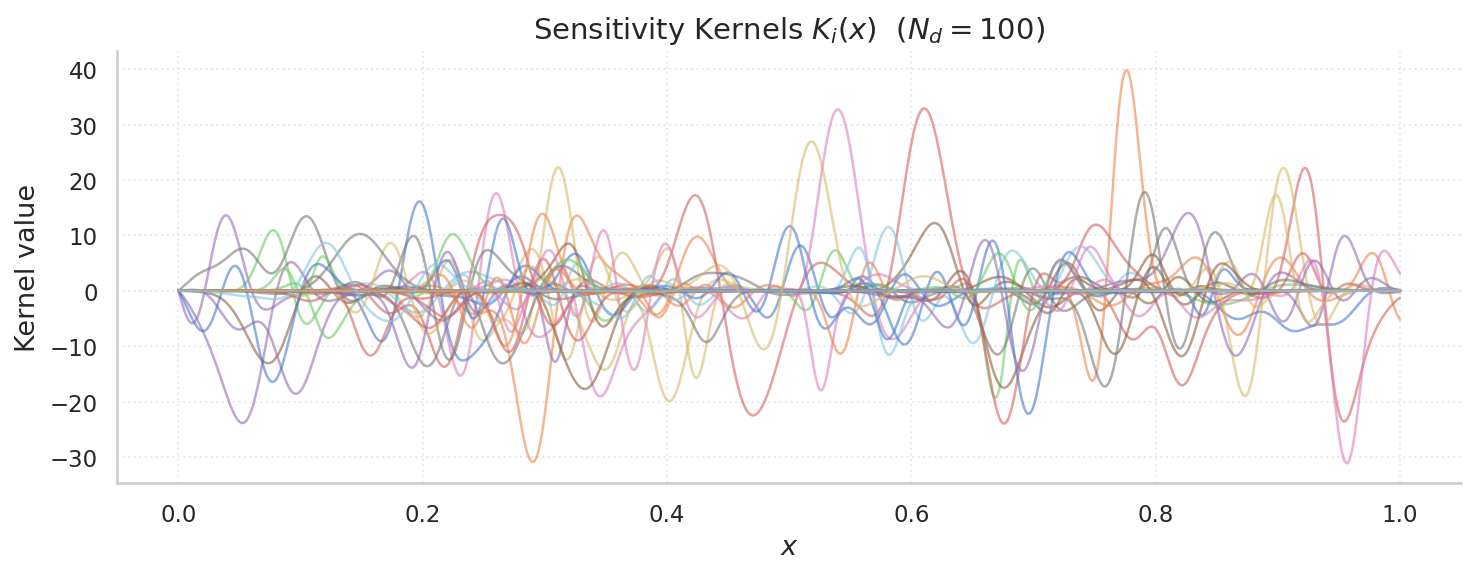

In [5]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", color_codes=True)

# -- Sensitivity kernels K_i (forward operator G) --
fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
for i in range(N_d):
    ax.plot(x, G.get_kernel(i).evaluate(x),
            linewidth=1.2 if N_d > 20 else 1.8, alpha=0.6 if N_d > 20 else 0.8,
            label=f'$K_{{{i}}}(x)$' if N_d <= 10 else None)
ax.set_title(fr"Sensitivity Kernels $K_i(x)$  ($N_d = {N_d}$)", fontsize=14)
ax.set_xlabel(r"$x$", fontsize=13)
ax.set_ylabel("Kernel value", fontsize=13)
ax.grid(True, linestyle=':', alpha=0.4)
if N_d <= 10:
    ax.legend(fontsize=9, ncol=2)
sns.despine()
plt.tight_layout()
fname = os.path.join(figures_folder, "sensitivity_kernels.png")
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.savefig(fname.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

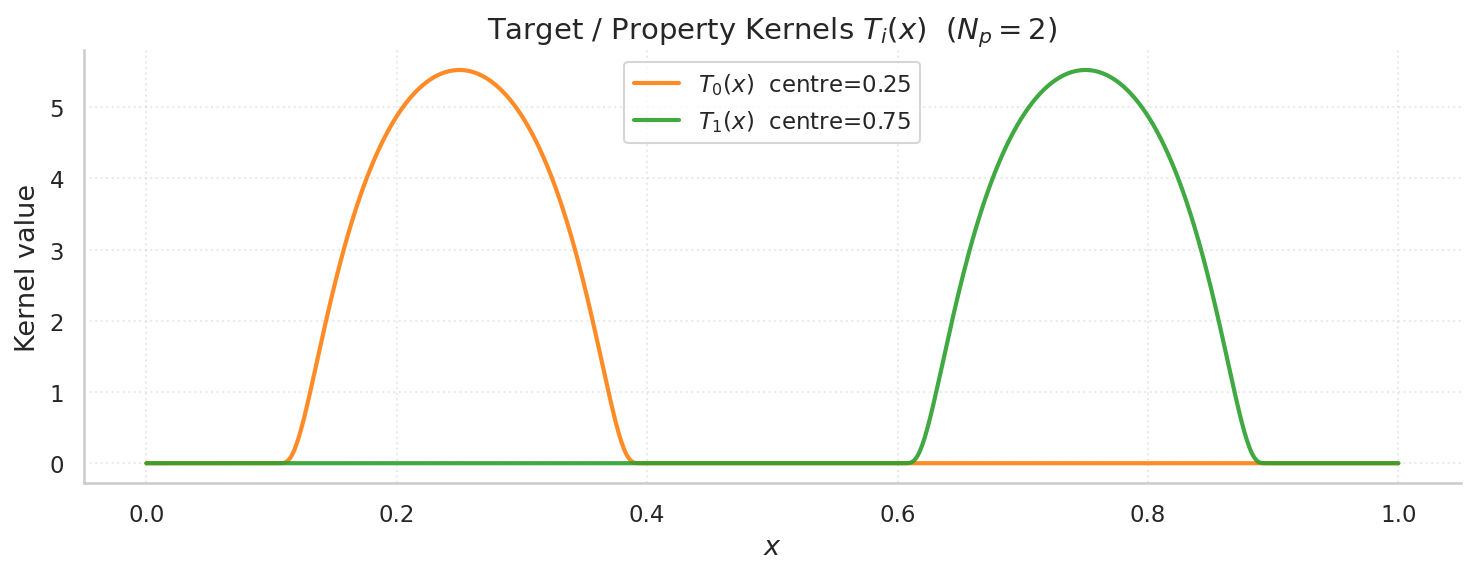

In [6]:
# -- Target / property kernels T_i (property operator T) --
fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
colors = ['tab:orange', 'tab:green']
for i in range(N_p):
    ax.plot(x, T.get_kernel(i).evaluate(x),
            color=colors[i], linewidth=2.0, alpha=0.9,
            label=f'$T_{{{i}}}(x)$  centre={centers[i]:.2f}')
ax.set_title(r"Target / Property Kernels $T_i(x)$  ($N_p = 2$)", fontsize=14)
ax.set_xlabel(r"$x$", fontsize=13)
ax.set_ylabel("Kernel value", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
fname = os.path.join(figures_folder, "target_kernels.png")
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.savefig(fname.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

## Synthetic Data Generation

### True Model

We use the same synthetic true model as in `dli.ipynb`:

$$
\bar{m}(x) = \exp\!\left(-\frac{(x-0.5)^2}{0.5^2}\right)\sin(5\pi x) + x.
$$

### Noise Model

For fair comparisons across different values of $N_d$, the notebook now keeps the **noise law** fixed in a principled way instead of fitting the confidence set to the realised noise draw.

- The per-datum noise level is set from the **RMS clean-data amplitude** rather than the maximum datum, so increasing $N_d$ does not automatically inflate $\sigma_d$.
- The confidence ellipsoid uses a fixed probability level $1-\beta$ through the $\chi^2_{N_d}$ quantile, so the set reflects the assumed Gaussian law rather than the specific realised sample.

Thus, when you change $N_d$, you are comparing different data dimensions under the same noise-model design, rather than changing both the amount of data and the uncertainty model at once.

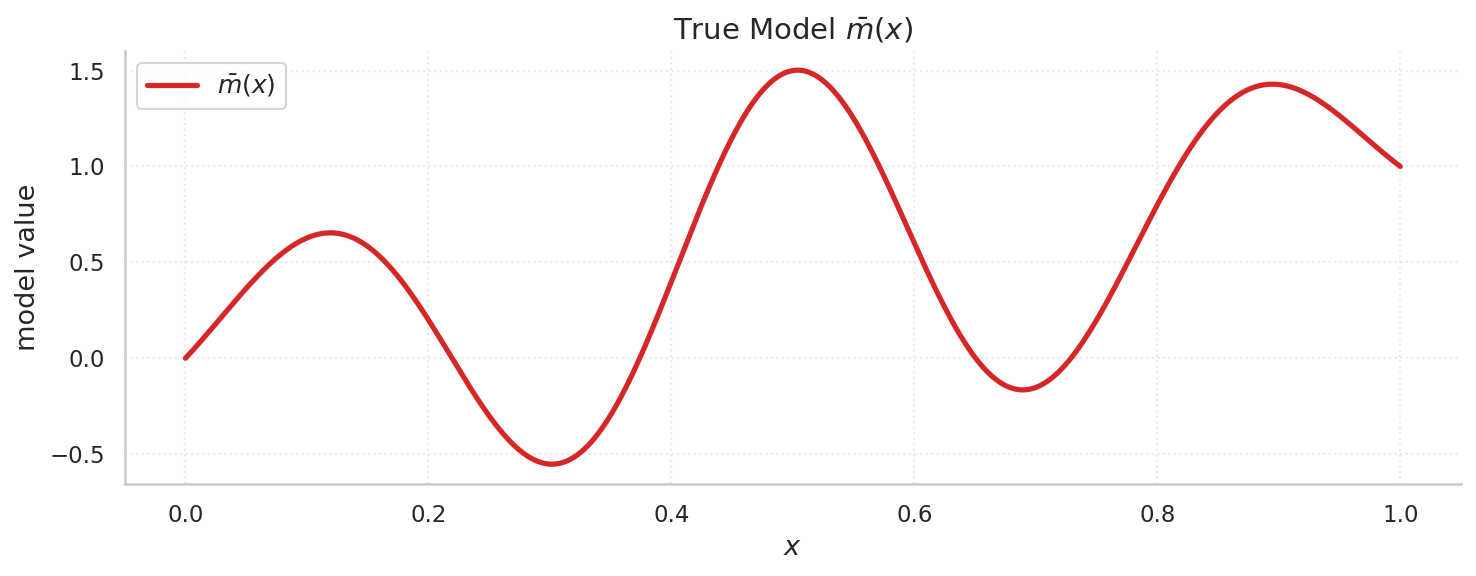

signal RMS       = 0.2700
sigma_d          = 0.0270
||noise||        = 0.2456
RMS SNR          = 10.0


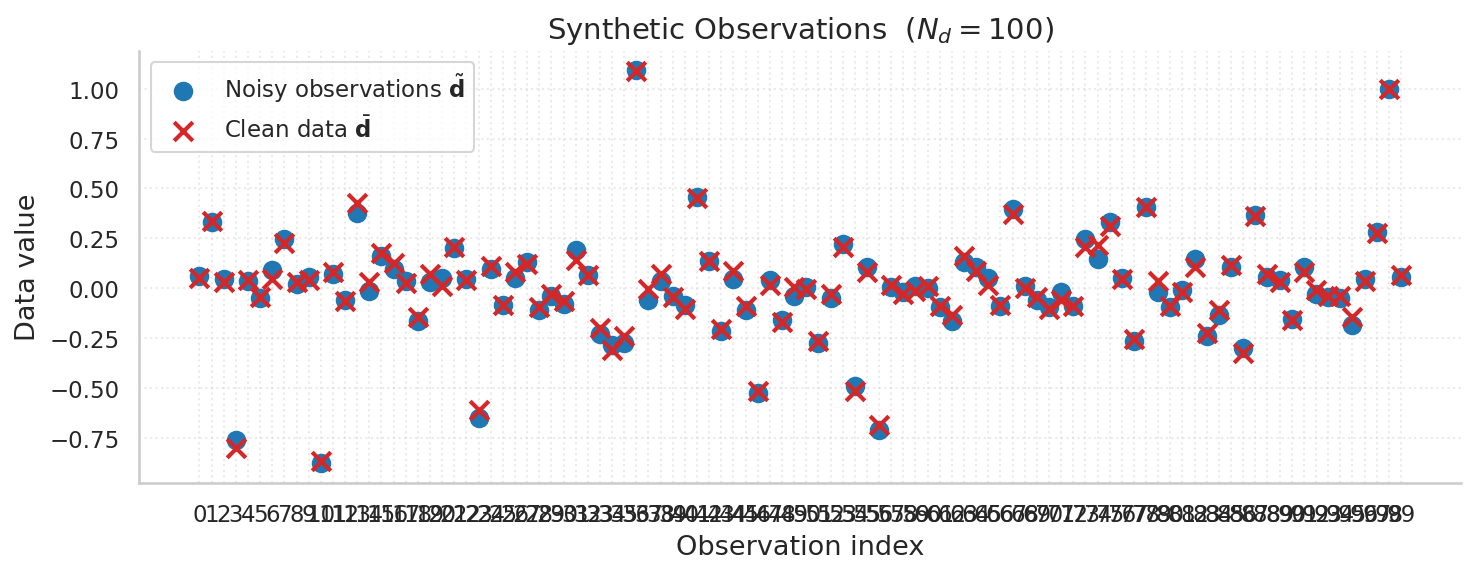

In [7]:
# ---- True model (same formula as dli.ipynb) ----
m_bar = Function(
    M,
    evaluate_callable=lambda x: np.exp(-((x - function_domain.center) / 0.5) ** 2)
                                * np.sin(5 * np.pi * x) + x,
)

fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
ax.plot(x, m_bar.evaluate(x), color='tab:red', linewidth=2.5, label=r'$\bar{m}(x)$')
ax.set_title(r"True Model $\bar{m}(x)$", fontsize=14)
ax.set_xlabel(r"$x$", fontsize=13)
ax.set_ylabel("model value", fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, "true_model.png"), dpi=150, bbox_inches='tight')
plt.show()

# ---- Noise model and synthetic noisy data ----
# Use a fixed per-datum noise rule based on RMS clean-data amplitude so
# changing N_d does not automatically inflate sigma_d through a larger max datum.
d_bar = G(m_bar)
signal_rms = np.linalg.norm(d_bar) / np.sqrt(N_d)
noise_fraction = 0.10
sigma_d = noise_fraction * signal_rms
C_d_diag = sigma_d ** 2 * np.ones(N_d)  # diagonal of C_d = sigma_d^2 * I

np.random.seed(42)
noise_vector = np.random.normal(0.0, sigma_d, N_d)
d_tilde = d_bar + noise_vector

print(f"signal RMS       = {signal_rms:.4f}")
print(f"sigma_d          = {sigma_d:.4f}")
print(f"||noise||        = {np.linalg.norm(noise_vector):.4f}")
print(f"RMS SNR          = {signal_rms / sigma_d:.1f}")

# ---- Data plot ----
fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
idx = np.arange(N_d)
for i in range(N_d):
    ax.plot([i, i], [d_bar[i], d_tilde[i]], color='gray', alpha=0.5, linewidth=1.0)
ax.scatter(idx, d_tilde, label='Noisy observations $\\tilde{\\mathbf{d}}$',
           color='tab:blue', s=70, zorder=3)
ax.scatter(idx, d_bar,   label='Clean data $\\bar{\\mathbf{d}}$',
           color='tab:red', marker='x', s=80, linewidths=2, zorder=4)
ax.set_title(f"Synthetic Observations  ($N_d = {N_d}$)", fontsize=14)
ax.set_xlabel("Observation index", fontsize=13)
ax.set_ylabel("Data value", fontsize=13)
ax.set_xticks(idx)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, "synthetic_observations.png"), dpi=150, bbox_inches='tight')
plt.show()

## Model Prior Ball and Data-Confidence Ellipsoid

### Model prior ball

We take the prior as a Hilbert ball

$$
\mathcal{B} = B_r(m_0), \qquad
m_0(x) = x, \qquad
r = 1.05\,\|\bar{m} - m_0\|_{\mathcal{M}}.
$$

Support function: $\sigma_{\mathcal{B}}(u) = \langle u, m_0\rangle_\mathcal{M} + r\|u\|_\mathcal{M}$.

### Data-confidence ellipsoid

For $\mathbf{C}_\mathcal{D} = \sigma_d^2 \mathbf{I}$ and confidence level $1-\beta$, we define

$$
\mathcal{V}_\mathcal{D} = \Bigl\{\mathbf{d} : \tfrac{1}{2}\langle \mathbf{C}_\mathcal{D}^{-1}\mathbf{d},\mathbf{d}\rangle \le s^2\Bigr\},
\qquad
s^2 = \tfrac{1}{2}\,\chi^2_{N_d, 1-\beta}.
$$

This gives a fixed probabilistic confidence rule across dimensions. The corresponding Euclidean radius is

$$
r_{\mathcal{V}} = s\sqrt{2}\,\sigma_d = \sigma_d\sqrt{\chi^2_{N_d,1-\beta}}.
$$

This is the right quantity to compare across runs: if $N_d$ changes, any change in the admissible set comes from the balance between better data constraints and the dimension-dependent confidence geometry, not from manually inflating the ellipsoid to fit the realised noise vector.

In [8]:
# ---- Model prior ball ----
m_0 = Function(M, evaluate_callable=lambda x: x)
model_radius = 1.05 * M.norm(M.subtract(m_bar, m_0))

model_prior_support = BallSupportFunction(M, m_0, model_radius)

print(f"model_radius r = {model_radius:.4f}")

# ---- Data-confidence ellipsoid (isotropic Gaussian noise) ----
# Use a fixed confidence level rather than fitting the ellipsoid to the realised noise.
confidence_level = 0.95
s_confidence = np.sqrt(0.5 * chi2.ppf(confidence_level, df=N_d))
noise_norm = np.linalg.norm(noise_vector)
r_data_conf = s_confidence * np.sqrt(2.0) * sigma_d

print(f"confidence level = {confidence_level:.2%}")
print(f"||noise||        = {noise_norm:.4f}")
print(f"s (chi-square)   = {s_confidence:.4f}")
print(f"r_V              = {r_data_conf:.4f}")

# Build LinearOperators for A, A^{-1}, A^{-1/2} as multiples of I on D
def _scalar_op(space, scale):
    """Return a self-adjoint scalar-multiple-of-identity LinearOperator."""
    return LinearOperator.self_adjoint(space, lambda v: scale * v)

A_op       = _scalar_op(D, 1.0 / (2.0 * sigma_d ** 2))      # A   = C_d^{-1}/2
A_inv_op   = _scalar_op(D, 2.0 * sigma_d ** 2)               # A^{-1} = 2 C_d
A_inv_sqrt = _scalar_op(D, np.sqrt(2.0) * sigma_d)           # A^{-1/2}

data_conf_ellipsoid = EllipsoidSupportFunction(
    D,
    center=D.zero,
    radius=s_confidence,
    shape_operator=A_op,
    inverse_operator=A_inv_op,
    inverse_sqrt_operator=A_inv_sqrt,
)

# Sanity check: h(q) = s * sqrt(2) * sigma_d * ||q||  for any q
q_test = np.ones(N_d)
h_ell  = data_conf_ellipsoid(q_test)
h_ref  = s_confidence * np.sqrt(2.0) * sigma_d * np.linalg.norm(q_test)
print(f"\nEllipsoid support-function check:")
print(f"  h(1,...,1) [ellipsoid] = {h_ell:.6f}")
print(f"  reference  value       = {h_ref:.6f}")
assert abs(h_ell - h_ref) < 1e-10, "Ellipsoid support function mismatch!"
print("  PASS")

model_radius r = 0.5753
confidence level = 95.00%
||noise||        = 0.2456
s (chi-square)   = 7.8849
r_V              = 0.3011

Ellipsoid support-function check:
  h(1,...,1) [ellipsoid] = 3.011019
  reference  value       = 3.011019
  PASS


## Optimal Linear Estimator $X^\star$ — Operator Form

The optimal estimator from the theory is

$$
X^\star = \mathcal{T}\,G^*\!\bigl(GG^* + 2s^2 r^{-2}\mathbf{C}_\mathcal{D}\bigr)^{-1} : \mathcal{D} \to \mathcal{P}.
$$

This should be built directly with the `pygeoinf` operator algebra rather than by hand-assembling Gram matrices. In particular, on the data space $\mathcal{D}$ we define

$$
A = GG^* + \alpha\,\mathbf{C}_\mathcal{D}, \qquad \alpha = 2s^2/r^2,
$$

and then form

$$
X^\star = \mathcal{T} G^* A^{-1}.
$$

For this small example we use a `CholeskySolver`, but the point is that the notebook works at the operator level: different direct or iterative solvers from `pygeoinf.linear_solvers` can be swapped in without changing the mathematical construction.

In [9]:
# Build X^* directly with pygeoinf operator algebra on the data space D.
# No explicit Gram or cross-Gram matrices are needed here.


# Data covariance as a self-adjoint operator on D
C_d_operator = _scalar_op(D, sigma_d ** 2)

# Regularisation parameter alpha = 2 s^2 / r^2
alpha = 2.0 * s_confidence ** 2 / model_radius ** 2

# Regularised data-space operator A = G G^* + alpha * C_d
regularized_data_operator = G @ G.adjoint + alpha * C_d_operator

# Choose any suitable pygeoinf inverse builder; Cholesky is fine for this SPD, low-dimensional problem
solver = CholeskySolver(parallel=True, n_jobs=parallel_cfg.n_jobs)
regularized_inverse = solver(regularized_data_operator)

# Optimal estimator operator X^*: D -> P
X_star_operator = T @ G.adjoint @ regularized_inverse

print("Operator construction complete:")
print(f"  alpha                        : {alpha:.4f}")
print(f"  regularized operator domain  : {regularized_data_operator.domain}")
print(f"  regularized operator codomain: {regularized_data_operator.codomain}")
print(f"  X_star_operator domain       : {X_star_operator.domain}")
print(f"  X_star_operator codomain     : {X_star_operator.codomain}")
print(f"  inverse builder              : {solver.__class__.__name__}")

Operator construction complete:
  alpha                        : 375.7540
  regularized operator domain  : <pygeoinf.hilbert_space.EuclideanSpace object at 0x7feb02b90950>
  regularized operator codomain: <pygeoinf.hilbert_space.EuclideanSpace object at 0x7feb02b90950>
  X_star_operator domain       : <pygeoinf.hilbert_space.EuclideanSpace object at 0x7feb02b90950>
  X_star_operator codomain     : <pygeoinf.hilbert_space.EuclideanSpace object at 0x7feb02c01f10>
  inverse builder              : CholeskySolver


## Phase 1 Summary

The setup is complete. The following objects are ready for Phase 2:

| Object | Description |
|--------|-------------|
| `M`, `D`, `P` | Model $L^2([0,1])$, data $\mathbb{R}^{N_d}$, property $\mathbb{R}^2$ |
| `G`, `T` | Forward and property SOLA operators (kernels cached) |
| `m_bar`, `d_bar`, `d_tilde` | True model, clean data, noisy data |
| `signal_rms`, `sigma_d` | RMS clean-data scale and fixed per-datum noise level |
| `confidence_level`, `s_confidence` | Probabilistic confidence level and the corresponding $\chi^2$ ellipsoid scale |
| `model_prior_support` | $\sigma_\mathcal{B}$ — `BallSupportFunction` around $m_0(x)=x$ |
| `data_conf_ellipsoid` | $\sigma_{\mathcal{V}_\mathcal{D}}$ — `EllipsoidSupportFunction` for $\mathbf{C}_\mathcal{D}=\sigma_d^2\mathbf{I}$ |
| `C_d_operator` | Covariance operator on the data space |
| `regularized_data_operator` | $GG^* + \alpha \mathbf{C}_\mathcal{D}$ on $\mathcal{D}$ |
| `regularized_inverse` | Inverse operator returned by a `pygeoinf` linear solver |
| `X_star_operator` | Optimal estimator operator $X^\star : \mathcal{D} \to \mathcal{P}$ |

**Phase 2** will:
1. Compute $\tilde{\mathbf{p}} = X^\star\tilde{\mathbf{d}}$ and $H = \mathcal{T} - X^\star G$.
2. Build the admissible support algebraically for $\tilde{\mathbf{p}} + H\mathcal{B} + X^\star\mathcal{V}_\mathcal{D}$.
3. Sample directional support values and assemble the two-dimensional admissible region.
4. Decompose the resulting width into model and data contributions for diagnosis.

## Phase 2 — Admissible Region in Property Space

### Theory

The admissible set satisfies:

$$
U \subseteq \tilde{\mathbf{p}} + H\mathcal{B} + X^\star \mathcal{V}_\mathcal{D},
$$

where:
- $\tilde{\mathbf{p}} = X^\star\tilde{\mathbf{d}} \in \mathcal{P}$ — the estimator point.
- $H = \mathcal{T} - X^\star G : \mathcal{M} \to \mathcal{P}$ — the residual operator (how model uncertainty maps into property uncertainty).
- $\mathcal{B} = B_r(m_0)$ — the model prior ball.
- $\mathcal{V}_\mathcal{D}$ — the data-confidence ellipsoid.

The **support function** of the Minkowski sum at direction $q \in \mathcal{P}$ is

$$
h_U(q) = \langle q,\, \tilde{\mathbf{p}} \rangle
         + \underbrace{h_\mathcal{B}(H^* q)}_{\text{model error}}
         + \underbrace{h_{\mathcal{V}_\mathcal{D}}\!\bigl((X^\star)^* q\bigr)}_{\text{data error}},
$$

using the pullback identity $h_{A(C)}(q) = h_C(A^*q)$.

Rather than implementing this formula manually, we use the **declarative support-function algebra** from `pygeoinf.convex_analysis`:
- `SupportFunction.point(P, p_t)` — singleton $\{\tilde{\mathbf{p}}\}$
- `model_prior_support.image(H_operator)` — image $H(\mathcal{B})$; adjoint pullback handled internally
- `data_conf_ellipsoid.image(X_star_operator)` — image $X^\star(\mathcal{V}_\mathcal{D})$; adjoint pullback handled internally
- Addition `+` computes the Minkowski sum.

Sampling $N_\theta$ unit directions $q_i$ and forming the halfspaces
$\{p : \langle q_i, p \rangle \leq h_U(q_i)\}$ gives a polyhedral outer approximation of $U$.


In [10]:
from pygeoinf.subsets import HalfSpace, PolyhedralSet

# ---- Estimator point p_t = X^* d_tilde ----
p_t = X_star_operator(d_tilde)     # R^{N_p} vector in property space
p_bar = T(m_bar)                   # true property (reference only)

# ---- Residual operator H = T - X^* G : M -> P ----
# H captures how model uncertainty propagates into property uncertainty.
# SOLAOperator and composed LinearOperators both inherit the LinearOperator
# algebra, so subtraction is exact (no matrix assembly).
H_operator = T - X_star_operator @ G

print("Phase 2 setup:")
print(f"  Estimated property p_t  = {p_t}")
print(f"  True property     p_bar = {p_bar}")
print(f"  Estimation error        = {p_t - p_bar}")
print(f"  H_operator domain       : {H_operator.domain}")
print(f"  H_operator codomain     : {H_operator.codomain}")

Phase 2 setup:
  Estimated property p_t  = [-0.1268983   0.31895004]
  True property     p_bar = [-0.13628501  0.36371499]
  Estimation error        = [ 0.00938671 -0.04476494]
  H_operator domain       : <intervalinf.spaces.lebesgue.Lebesgue object at 0x7feb02c4d150>
  H_operator codomain     : <pygeoinf.hilbert_space.EuclideanSpace object at 0x7feb02c01f10>


In [11]:
# ---- Compose the admissible-region support function algebraically ----
# The admissible set is  U ⊆ p_t + H(B) + X^*(V_D).
#
# Using the support-function algebra from pygeoinf.convex_analysis:
#   SupportFunction.point(P, p_t)            →  h(q) = <q, p_t>
#   model_prior_support.image(H_operator)    →  h(q) = h_B(H^* q)
#   data_conf_ellipsoid.image(X_star_operator) → h(q) = h_{V_D}((X^*)^* q)
#
# The adjoint pullbacks are handled internally by .image(); no explicit
# H_adj or X_star_adj construction is needed.

admissible_support = (
    SupportFunction.point(P, p_t)
    + model_prior_support.image(H_operator)
    + data_conf_ellipsoid.image(X_star_operator)
)

# ---- Sanity checks ----
_cardinal = [
    ("e_1",  np.array([1.0, 0.0])),
    ("e_2",  np.array([0.0, 1.0])),
    ("-e_1", np.array([-1.0, 0.0])),
    ("-e_2", np.array([0.0, -1.0])),
]
print("Support-function values at cardinal directions:")
for label, q in _cardinal:
    print(f"  h({label:5s}) = {admissible_support(q):+.6f}")

# p_bar must satisfy <q, p_bar>_P <= h(q) for every direction
_pass = all(P.inner_product(q, p_bar) <= admissible_support(q) + 1e-9 for _, q in _cardinal)
print(f"\np_bar inside admissible region (cardinal dirs): {_pass}")
assert _pass, "p_bar violates a cardinal halfspace — check operator construction!"


Support-function values at cardinal directions:
  h(e_1  ) = +0.104306
  h(e_2  ) = +0.848973
  h(-e_1 ) = +0.347597
  h(-e_2 ) = +0.098745

p_bar inside admissible region (cardinal dirs): True


In [12]:
# ---- Build polyhedral admissible region ----
# Sample N_theta uniformly-spaced unit directions in R^2.
# For each direction q_i, the halfspace {p : <q_i, p> <= h_U(q_i)}
# is one face of the polyhedral outer approximation.

N_theta = 20
angles = np.linspace(0, 2 * np.pi, N_theta, endpoint=False)

halfspaces = [
    HalfSpace(
        P,
        normal_vector=np.array([np.cos(t), np.sin(t)]),
        offset=admissible_support(np.array([np.cos(t), np.sin(t)])),
    )
    for t in angles
]

admissible_region = PolyhedralSet(P, half_spaces=halfspaces)

# Containment checks
print(f"p_t   in admissible_region : {admissible_region.is_element(p_t)}")
print(f"p_bar in admissible_region : {admissible_region.is_element(p_bar)}")

# Extract approximate diameter for diagnostics
_h_x  = admissible_support(np.array([1.0, 0.0]))
_h_y  = admissible_support(np.array([0.0, 1.0]))
_h_mx = admissible_support(np.array([-1.0, 0.0]))
_h_my = admissible_support(np.array([0.0, -1.0]))
print(f"\nApproximate admissible-region diameter:")
print(f"  x-extent : {_h_x + _h_mx:.4f}  (from {-_h_mx:.4f} to {_h_x:.4f})")
print(f"  y-extent : {_h_y + _h_my:.4f}  (from {-_h_my:.4f} to {_h_y:.4f})")


p_t   in admissible_region : True
p_bar in admissible_region : True

Approximate admissible-region diameter:
  x-extent : 0.4519  (from -0.3476 to 0.1043)
  y-extent : 0.9477  (from -0.0987 to 0.8490)


In [13]:
# ---- Width decomposition diagnostics ----
model_support_image = model_prior_support.image(H_operator)
data_support_image = data_conf_ellipsoid.image(X_star_operator)

def directional_width(support_obj, q):
    return support_obj(q) + support_obj(-q)

directions = {
    'x': np.array([1.0, 0.0]),
    'y': np.array([0.0, 1.0]),
}

print("Width decomposition by contribution:")
for axis, q in directions.items():
    model_width = directional_width(model_support_image, q)
    data_width = directional_width(data_support_image, q)
    total_width = directional_width(admissible_support, q)
    print(f"  {axis}-axis total = {total_width:.4f}")
    print(f"    model term      = {model_width:.4f}")
    print(f"    data term       = {data_width:.4f}")

print("\nFair-comparison calibration:")
print(f"  sigma_d from RMS signal scale = {sigma_d:.4f}")
print(f"  confidence level              = {confidence_level:.2%}")
print(f"  chi-square radius r_V         = {r_data_conf:.4f}")
print("  Interpretation: changing N_d now changes the geometry through the model/data operators")
print("  and the chi-square confidence rule, not by fitting the ellipsoid to the realised noise sample.")

Width decomposition by contribution:
  x-axis total = 0.4519
    model term      = 0.0821
    data term       = 0.3698
  y-axis total = 0.9477
    model term      = 0.3175
    data term       = 0.6303

Fair-comparison calibration:
  sigma_d from RMS signal scale = 0.0270
  confidence level              = 95.00%
  chi-square radius r_V         = 0.3011
  Interpretation: changing N_d now changes the geometry through the model/data operators
  and the chi-square confidence rule, not by fitting the ellipsoid to the realised noise sample.


## Width Diagnostics

To understand why the admissible region changes with $N_d$, it is useful to decompose the directional width into

$$
h_{H\mathcal{B}}(q) \quad \text{and} \quad h_{X^\star\mathcal{V}_\mathcal{D}}(q).
$$

The first term is the propagated model uncertainty; the second is the propagated data uncertainty. If the data term grows faster than the residual-model term shrinks, the total property set can stay the same size or even get larger despite using more data.

INFO:matplotlib.mathtext:Substituting symbol B from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol T from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol B from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol T from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol B from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol D from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol T from STIXNonUni

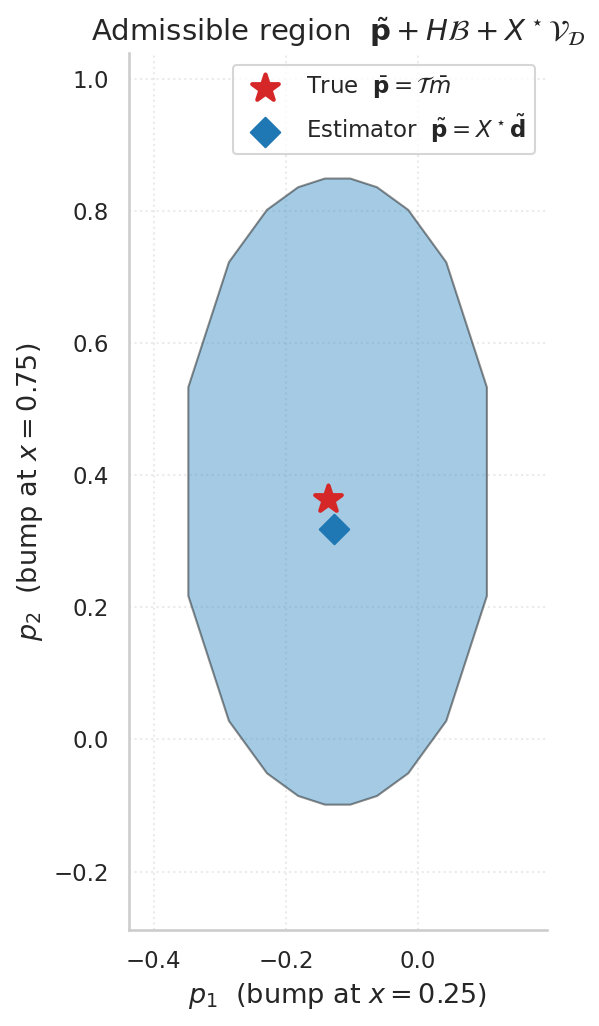

Figure saved: bg_with_errors_minkowski_figures/admissible_region.png


In [14]:
# ---- Visualise the admissible region ----
# Bounds: pad by 20% of the x/y diameter around the region
_pad_x = 0.20 * (_h_x + _h_mx)
_pad_y = 0.20 * (_h_y + _h_my)
_bounds = (
    -_h_mx - _pad_x, _h_x + _pad_x,
    -_h_my - _pad_y, _h_y + _pad_y,
)

fig, ax = plt.subplots(figsize=(7, 7), dpi=150)

# PolyhedralSet.plot() takes the fast exact path via HalfspaceIntersection
admissible_region.plot(bounds=_bounds, ax=ax, show_plot=False, cmap="Blues", alpha=0.5)

# Overlay the true property and estimator
ax.scatter(
    *p_bar, color='tab:red', s=180, zorder=6, linewidths=2.0,
    marker='*', label=r'True  $\bar{\mathbf{p}} = \mathcal{T}\bar{m}$',
)
ax.scatter(
    *p_t, color='tab:blue', s=100, zorder=6,
    marker='D', label=r'Estimator  $\tilde{\mathbf{p}} = X^\star\tilde{\mathbf{d}}$',
)

ax.set_xlabel(r'$p_1$  (bump at $x = 0.25$)', fontsize=13)
ax.set_ylabel(r'$p_2$  (bump at $x = 0.75$)', fontsize=13)
ax.set_title(
    r'Admissible region  $\tilde{\mathbf{p}} + H\mathcal{B} + X^\star\mathcal{V}_\mathcal{D}$',
    fontsize=14,
)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()

_fname = os.path.join(figures_folder, "admissible_region.png")
plt.savefig(_fname, dpi=150, bbox_inches='tight')
plt.savefig(_fname.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

print(f"Figure saved: {_fname}")